In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from model.logistic_regression_model import make_logistic_regression
from model.decision_tree_model import make_decision_tree
from model.knn_model import make_knn
from model.naive_bayes_model import make_naive_bayes
from model.random_forest_model import make_random_forest

from metrics import compute_binary_metrics

In [2]:
# Load data
df = pd.read_csv("data/breast_cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


**Exploratory Data Analysis (EDA)**


In [3]:
print("dataset size")
print(df.shape)

print("\nmissing values")
print(df.isna().sum())

print("\nfeature types")
print(df.dtypes)

dataset size
(569, 33)

missing values
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0


In [4]:
# Clean extra columns and target encoding
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")
df["diagnosis"] = df["diagnosis"].astype(str).str.strip()
df["target_bin"] = (df["diagnosis"] == "M").astype(int)

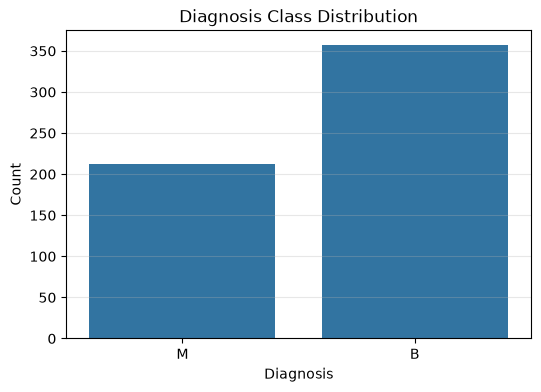

In [5]:
# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
dtype: float64


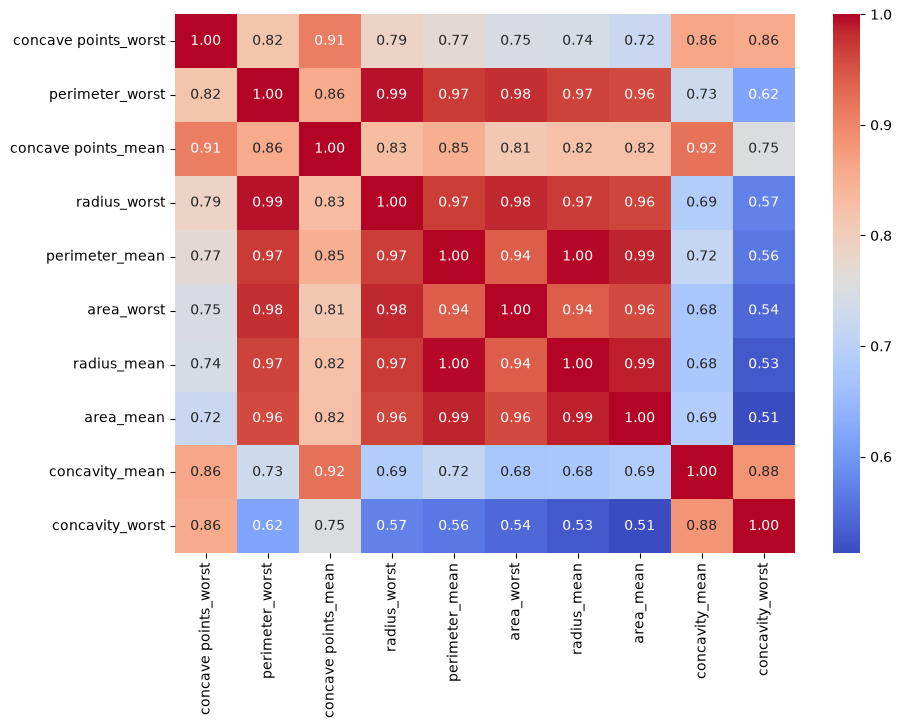

In [6]:
X_num = df.select_dtypes(include=[np.number]).drop(
    columns=["target_bin"], errors="ignore"
)
corr_with_target = X_num.corrwith(df["target_bin"]).abs().sort_values(ascending=False)

top10_features = corr_with_target.head(10).index.tolist()
print(corr_with_target.head(10))

plt.figure(figsize=(10, 7))
sns.heatmap(df[top10_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [7]:
X = df.drop(columns=["diagnosis", "target_bin"])
y = df["target_bin"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
models = {
    "Logistic Regression": make_logistic_regression(),
    "Decision Tree": make_decision_tree(),
    "kNN": make_knn(),
    "Naive Bayes": make_naive_bayes(),
    "Random Forest (Ensemble)": make_random_forest(),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= 0.35).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_proba = None

    m = compute_binary_metrics(y_test, y_pred, y_proba)

    results.append(
        {
            "Model": name,
            "Accuracy": m["accuracy"],
            "AUC Score": m["auc"],
            "Precision": m["precision"],
            "Recall": m["recall"],
            "F1 Score": m["f1"],
            "Matthews Correlation Coefficient (MCC Score)": m["mcc"],
        }
    )

results_df = (
    pd.DataFrame(results)
)
results_df

,Model,Accuracy,AUC Score,Precision,Recall,F1 Score,Matthews Correlation Coefficient (MCC Score)
0,Logistic Regression,0.964912,0.997024,0.931818,0.976190,0.953488,0.925989
1,Decision Tree,0.921053,0.948413,0.902439,0.880952,0.891566,0.829660
2,kNN,0.956140,0.983466,0.974359,0.904762,0.938272,0.905824
3,Naive Bayes,0.982456,0.997354,0.976190,0.976190,0.976190,0.962302
4,Random Forest (Ensemble),0.964912,0.998016,0.975000,0.928571,0.951220,0.924518


In [10]:
SAVED_DIR = "model/saved"
MODEL_TO_FILE = {
    "Logistic Regression": "logistic_regression.joblib",
    "Decision Tree": "decision_tree.joblib",
    "kNN": "knn.joblib",
    "Naive Bayes": "naive_bayes.joblib",
    "Random Forest (Ensemble)": "random_forest.joblib"
}

for name, model in models.items():
    path = os.path.join(SAVED_DIR, MODEL_TO_FILE[name])
    joblib.dump(model, path)